# 24 — Application Gradient Boosting and Policy Freeze

This notebook constructs the leakage-safe application feature panel, selects one small-capacity Gradient Boosting specification using C → VALIDATION, freezes the policy design, refits on C+VALIDATION, and creates a TEST prediction/policy handoff. N22 and N23 are frozen inputs. TEST economic outcomes are never loaded or evaluated.

## 24.1 Scope and frozen application design

C is part of the **retrospective chronological reconstruction conditional on the final fixed specification**: its ordinary forecasts were fitted from A+B without their own target outcomes, but the final upstream architectures were selected retrospectively using broader pre-TEST information. It is not presented as a prospective or live backtest. C is the N24 fitting block and VALIDATION is the later pre-TEST selection block.

The >=3-model requirement for N24 forecast-consensus features is an application-stage support rule fixed before the final TEST economic evaluation. A median could mathematically be computed from two forecasts, but N24 requires at least three of the four frozen models to maintain a stable multi-model consensus and to remain consistent with the support standard used by the upstream detector.

In [1]:
from pathlib import Path
from itertools import product
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

PROJECT_MARKER = "00_model_specification_and_core_simulator.ipynb"

def find_project_root(start=None):
    """Find the project from the current directory or one of its parents."""
    start = (Path.cwd() if start is None else Path(start)).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "Data").is_dir() and (candidate / PROJECT_MARKER).is_file():
            return candidate
    raise RuntimeError(
        "Could not locate the FX volatility project root. "
        "Start the notebook from the project directory or one of its subdirectories; "
        f"expected both Data/ and {PROJECT_MARKER}."
    )

PROJECT = find_project_root()
PROCESSED, FIGURES = PROJECT / 'Data' / 'processed', PROJECT / 'figures'
FIGURES.mkdir(exist_ok=True)

MODELS = ['RF', 'GB', 'MLP', 'TRANSFORMER']
BASE_FEATURES = ['Q_t','R_t','I_t','Fhat_R_adm_t1','Fhat_I_adm_t1','S_t1_given_t']
HIDDEN_FEATURES = ['Delta_L_t','common_log_response_t','P_R_t','P_I_prev_t']
ALL_FEATURES, SUPPORT_FLOOR = BASE_FEATURES + HIDDEN_FEATURES, 3
GRID = list(product([100,250],[.03,.05],[1,2],[20,40]))
NOISE_SEEDS, GB_RANDOM_STATE = [19,119,219], 19
# Explicit frozen upstream fingerprint set: canonical N14–N23, with optional N18A; N24 is excluded.
UPSTREAM_PREFIXES=['14_','15_','16_','17_','18_','19_','20_','21_','22_','23_']
UPSTREAM_NOTEBOOKS=[]
for prefix in UPSTREAM_PREFIXES:
    matches=sorted(PROJECT.glob(prefix+'*.ipynb'))
    assert len(matches)==1, (prefix,matches)
    UPSTREAM_NOTEBOOKS.extend(matches)
UPSTREAM_NOTEBOOKS.extend(sorted(PROJECT.glob('18A_*.ipynb')))
assert all(not path.name.startswith('24_') for path in UPSTREAM_NOTEBOOKS)
def file_hash(path): return hashlib.sha256(path.read_bytes()).hexdigest()
UPSTREAM_HASH_BEFORE={path.name:file_hash(path) for path in UPSTREAM_NOTEBOOKS}

def read(name, **kw): return pd.read_csv(PROCESSED / name, **kw)
def finite(df, cols):
    return df[cols].apply(lambda x: np.isfinite(pd.to_numeric(x, errors='coerce'))).all(axis=1)
def metrics(y, yhat):
    mse=mean_squared_error(y,yhat)
    corr=np.corrcoef(y,yhat)[0,1] if np.std(y)>0 and np.std(yhat)>0 else np.nan
    return {'MSE':float(mse),'RMSE':float(np.sqrt(mse)),'MAE':float(mean_absolute_error(y,yhat)),'correlation':float(corr)}
def params(r):
    return dict(loss='squared_error',subsample=1.,random_state=GB_RANDOM_STATE,
                n_estimators=int(r.n_estimators),learning_rate=float(r.learning_rate),
                max_depth=int(r.max_depth),min_samples_leaf=int(r.min_samples_leaf))
def action(yhat, cl, cs): return np.where(yhat>cl,1,np.where(yhat<-cs,-1,0)).astype(int)
def counts(z):
    z=np.asarray(z); n=int((z!=0).sum())
    return {'n_long':int((z==1).sum()),'n_flat':int((z==0).sum()),'n_short':int((z==-1).sum()),
            'n_trade':n,'long_share_conditional_trade':float((z==1).sum()/n) if n else np.nan,
            'short_share_conditional_trade':float((z==-1).sum()/n) if n else np.nan}
def net(z, yl, ys): return np.where(z==1,yl,np.where(z==-1,ys,0.))
def econ(z, yl, ys):
    p=net(z,yl,ys); tr=np.asarray(z)!=0; cum=np.cumsum(p); dd=cum-np.maximum.accumulate(np.r_[0.,cum])[1:]
    return {'n_days':len(p),**counts(z),'mean_daily_net_pnl':float(p.mean()),'median_daily_net_pnl':float(np.median(p)),
            'std_daily_net_pnl':float(p.std(ddof=1)),'best_day':float(p.max()),'worst_day':float(p.min()),
            'mean_net_pnl_conditional_trade':float(p[tr].mean()) if tr.any() else np.nan,
            'median_net_pnl_conditional_trade':float(np.median(p[tr])) if tr.any() else np.nan,
            'trade_hit_rate':float((p[tr]>0).mean()) if tr.any() else np.nan,
            'cumulative_net_pnl':float(cum[-1]),'maximum_drawdown':float(dd.min()),
            'J':float(p.mean()/p.std(ddof=1)) if p.std(ddof=1)>0 else np.nan}

## 24.2–24.3 Inputs, chronology and decision-time feature construction

Feature-availability gaps show a recurring seasonal pattern concentrated around early November and the year-end period. The early-November clustering coincides with the US DST transition, but N24 treats this as an availability pattern rather than assigning an unverified causal mechanism. Early C’s weaker completeness is an inherited upstream implied-model-support limitation; no rows are reweighted, repaired, or imputed.

In [2]:
# Canonical observed chronology and state variables.
core=read('16_empirical_analysis_panel.csv',parse_dates=['model_day']).sort_values('model_day').reset_index(drop=True)
core=core.rename(columns={'squared_return':'Q_t','realised_variance_ann_252':'R_t','iv_model_var':'I_t'})
core['previous_observed_model_day']=core.model_day.shift(1)
core['next_observed_model_day']=core.model_day.shift(-1)
assert core.model_day.is_unique

# Pre-TEST only: outcomes may be loaded for C/VALIDATION policy diagnostics.
pc=['model_day','stage','contract_admissible','Y_gross','episode_entry','Delta_L','common_log_response','P_R','P_I_prev']
pre_contract=read('23_contract_admissibility_panel.csv',parse_dates=['model_day'],usecols=pc)
pre_contract=pre_contract[pre_contract.stage.isin(['C','VALIDATION']) & pre_contract.contract_admissible.fillna(False)].copy()
assert pre_contract.groupby('stage').size().to_dict()=={'C':961,'VALIDATION':961}
cost=read('23_cost_grid_panel.csv',parse_dates=['model_day'],usecols=['model_day','stage','s_sigma_label','c_entry_L','c_entry_S','Y_net_L','Y_net_S'])
cost=cost[cost.stage.isin(['C','VALIDATION']) & cost.s_sigma_label.eq('BASE')].drop(columns='s_sigma_label')
pre_contract=pre_contract.merge(cost,on=['model_day','stage'],how='left',validate='one_to_one')
assert pre_contract[['c_entry_L','c_entry_S','Y_net_L','Y_net_S']].notna().all().all()

# Exact N22 C export plus frozen N21 admitted forecasts for VALIDATION/TEST.
cf=read('22_historical_C_model_level_ordinary_forecasts.csv',parse_dates=['forecast_target_model_day'])
cf=cf[['forecast_target_model_day','target','model','admissible_forecast']].rename(columns={'admissible_forecast':'forecast'}).assign(stage='C')
ff=read('21_empirical_log_response_scores.csv',parse_dates=['model_day'],usecols=['model_day','sample_split','target','model','admissible_forecast'])
ff=ff[ff.sample_split.isin(['validation','test'])].rename(columns={'model_day':'forecast_target_model_day','admissible_forecast':'forecast'})
ff['stage']=ff.sample_split.map({'validation':'VALIDATION','test':'TEST'})
fore=pd.concat([cf,ff[['forecast_target_model_day','target','model','forecast','stage']]],ignore_index=True)
fore['model']=fore.model.str.upper()
fore=fore[fore.target.isin(['R','I']) & fore.model.isin(MODELS)].copy()
mapt=core[['model_day','previous_observed_model_day']].rename(columns={'model_day':'forecast_target_model_day','previous_observed_model_day':'decision_model_day'})
fore=fore.merge(mapt,on='forecast_target_model_day',how='left').merge(
    core[['model_day','next_observed_model_day']].rename(columns={'model_day':'decision_model_day'}),on='decision_model_day',how='left')
assert fore.decision_model_day.notna().all()
assert fore.forecast_target_model_day.eq(fore.next_observed_model_day).all()

def features(contract, outcomes):
    f=fore.merge(contract[['model_day','stage']].rename(columns={'model_day':'decision_model_day'}),
                 on=['decision_model_day','stage'],how='inner')
    w=f.pivot_table(index=['decision_model_day','stage','forecast_target_model_day'],columns=['target','model'],values='forecast',aggfunc='first')
    w.columns=[f'{a}_{b}' for a,b in w.columns]; w=w.reset_index()
    for target in ['R','I']:
        cols=[f'{target}_{m}' for m in MODELS]
        for col in cols:
            if col not in w: w[col]=np.nan
        a=w[cols].apply(pd.to_numeric,errors='coerce')
        w[f'{target}_model_support']=a.notna().sum(axis=1)
        w[f'Fhat_{target}_adm_t1']=a.median(axis=1)
    w=w.merge(core[['model_day','Q_t','R_t','I_t']].rename(columns={'model_day':'decision_model_day'}),on='decision_model_day',how='left')
    comps=[]
    for _,r in w.iterrows():
        v=[np.log(r.I_t/r[f'R_{m}']) for m in MODELS if pd.notna(r[f'R_{m}']) and r[f'R_{m}']>0 and pd.notna(r.I_t) and r.I_t>0]
        comps.append(float(np.median(v)) if len(v)>=SUPPORT_FLOOR else np.nan)
    w['S_t1_given_t']=comps
    x=contract.rename(columns={'model_day':'decision_model_day','Delta_L':'Delta_L_t','common_log_response':'common_log_response_t','P_R':'P_R_t','P_I_prev':'P_I_prev_t'})
    x=x.merge(w[['decision_model_day','stage','forecast_target_model_day','Q_t','R_t','I_t','Fhat_R_adm_t1','Fhat_I_adm_t1','S_t1_given_t','R_model_support','I_model_support']],on=['decision_model_day','stage'],how='left')
    x['BASE_feature_finite']=finite(x,BASE_FEATURES); x['hidden_coordinates_complete']=finite(x,HIDDEN_FEATURES)
    x['BASE_complete']=x.BASE_feature_finite & x.R_model_support.ge(3) & x.I_model_support.ge(3)
    x['COMMON_complete']=x.BASE_complete & x.hidden_coordinates_complete
    if outcomes: x['COMMON_complete'] &= np.isfinite(x.Y_gross)
    return x

pre_panel=features(pre_contract,True).sort_values(['stage','decision_model_day']).reset_index(drop=True)
assert pre_panel.groupby('stage').COMMON_complete.sum().to_dict()=={'C':805,'VALIDATION':902}
assert pre_panel[pre_panel.COMMON_complete].groupby('stage').episode_entry.sum().to_dict()=={'C':68,'VALIDATION':34}
c=pre_panel[(pre_panel.stage=='C') & pre_panel.COMMON_complete].copy()
v=pre_panel[(pre_panel.stage=='VALIDATION') & pre_panel.COMMON_complete].copy()
assert len(c)==805 and len(v)==902 and finite(pd.concat([c,v]),BASE_FEATURES+HIDDEN_FEATURES).all()

feature_definition=pd.DataFrame([
 {'feature':x,'role':'BASE','timing':'decision t / next observed t+1'} for x in BASE_FEATURES]+
 [{'feature':x,'role':'HIDDEN_AWARE_ADDITION','timing':'frozen N22 decision-time coordinate'} for x in HIDDEN_FEATURES])
availability=pre_panel.groupby('stage').agg(N23_admissible=('decision_model_day','size'),BASE_feature_finite=('BASE_feature_finite','sum'),
 R_support_ge_3=('R_model_support',lambda x:int((x>=3).sum())),I_support_ge_3=('I_model_support',lambda x:int((x>=3).sum())),
 BASE_complete=('BASE_complete','sum'),hidden_coordinates_complete=('hidden_coordinates_complete','sum'),COMMON_complete=('COMMON_complete','sum')).reset_index()
display(feature_definition); display(availability)

,feature,role,timing
0,Q_t,BASE,decision t / next observed t+1
1,R_t,BASE,decision t / next observed t+1
2,I_t,BASE,decision t / next observed t+1
3,Fhat_R_adm_t1,BASE,decision t / next observed t+1
4,Fhat_I_adm_t1,BASE,decision t / next observed t+1
5,S_t1_given_t,BASE,decision t / next observed t+1
6,Delta_L_t,HIDDEN_AWARE_ADDITION,frozen N22 decision-time coordinate
7,common_log_response_t,HIDDEN_AWARE_ADDITION,frozen N22 decision-time coordinate
8,P_R_t,HIDDEN_AWARE_ADDITION,frozen N22 decision-time coordinate
9,P_I_prev_t,HIDDEN_AWARE_ADDITION,frozen N22 decision-time coordinate


,stage,N23_admissible,BASE_feature_finite,R_support_ge_3,I_support_ge_3,BASE_complete,hidden_coordinates_complete,COMMON_complete
0,C,961,915,915,856,844,817,805
1,VALIDATION,961,948,948,914,913,903,902


## 24.4–24.5 Feature/timing/support audits and BASE selection

The six BASE features deliberately contain related information: \(I_t\) and the realised forecast appear both directly and inside the relative-value feature. Raw IV is not a GB predictor because it is mechanically coupled to N23’s premium-normalised target, not because it is unavailable at decision time.

In [3]:
candidate=[]
for cid,(ne,lr,depth,leaf) in enumerate(GRID,1):
    r=pd.Series({'n_estimators':ne,'learning_rate':lr,'max_depth':depth,'min_samples_leaf':leaf})
    m=GradientBoostingRegressor(**params(r)).fit(c[BASE_FEATURES],c.Y_gross)
    tr=m.predict(c[BASE_FEATURES]); va=m.predict(v[BASE_FEATURES]); mm=metrics(v.Y_gross,va)
    candidate.append({'candidate_id':cid,**r.to_dict(),'C_training_MSE':mean_squared_error(c.Y_gross,tr),
                      'VALIDATION_MSE':mm['MSE'],'VALIDATION_RMSE':mm['RMSE'],'VALIDATION_MAE':mm['MAE'],
                      'VALIDATION_prediction_target_correlation':mm['correlation']})
candidate_selection=pd.DataFrame(candidate)
min_mse=candidate_selection.VALIDATION_MSE.min()
winner=candidate_selection[candidate_selection.VALIDATION_MSE.eq(min_mse)].sort_values(
    ['max_depth','n_estimators','min_samples_leaf','learning_rate'],ascending=[True,True,False,True]).iloc[0].copy()
candidate_selection['winner']=candidate_selection.candidate_id.eq(winner.candidate_id)
assert len(candidate_selection)==16 and candidate_selection.winner.sum()==1
depth_best=candidate_selection.groupby('max_depth',as_index=False).VALIDATION_MSE.min()
d1=float(depth_best.loc[depth_best.max_depth.eq(1),'VALIDATION_MSE'].iloc[0]); d2=float(depth_best.loc[depth_best.max_depth.eq(2),'VALIDATION_MSE'].iloc[0])
depth_comparison=pd.DataFrame([{'best_depth_1_VALIDATION_MSE':d1,'best_depth_2_VALIDATION_MSE':d2,
 'absolute_difference':abs(d1-d2),'percentage_difference_relative_to_better':abs(d1-d2)/min(d1,d2)*100,'winning_depth':int(winner.max_depth)}])
display(candidate_selection); display(depth_comparison)
print('Winner selected solely by unrounded VALIDATION MSE:',dict(winner[['n_estimators','learning_rate','max_depth','min_samples_leaf','VALIDATION_MSE']]))
if int(winner.max_depth)==1: print('Depth 1 wins: the selected learner is primarily additive nonlinear; HIDDEN_AWARE is correspondingly a narrower interaction test.')

,candidate_id,n_estimators,learning_rate,max_depth,min_samples_leaf,C_training_MSE,VALIDATION_MSE,VALIDATION_RMSE,VALIDATION_MAE,VALIDATION_prediction_target_correlation,winner
0,1,100.0,0.03,1.0,20.0,0.115735,0.240547,0.490456,0.271433,0.005802,False
1,2,100.0,0.03,1.0,40.0,0.115942,0.240131,0.490032,0.271029,0.020720,False
2,3,100.0,0.03,2.0,20.0,0.108677,0.237419,0.487257,0.269730,0.008791,False
3,4,100.0,0.03,2.0,40.0,0.110895,0.235594,0.485381,0.267668,0.026727,False
4,5,100.0,0.05,1.0,20.0,0.114818,0.240292,0.490196,0.271261,0.009962,False
5,6,100.0,0.05,1.0,40.0,0.115111,0.239892,0.489788,0.270775,0.020227,False
6,7,100.0,0.05,2.0,20.0,0.104488,0.237125,0.486954,0.270567,0.003639,False
7,8,100.0,0.05,2.0,40.0,0.107878,0.234131,0.483871,0.267556,0.031197,False
8,9,250.0,0.03,1.0,20.0,0.113919,0.239235,0.489117,0.270478,0.014638,False
9,10,250.0,0.03,1.0,40.0,0.114293,0.238825,0.488698,0.269847,0.020465,False


,best_depth_1_VALIDATION_MSE,best_depth_2_VALIDATION_MSE,absolute_difference,percentage_difference_relative_to_better,winning_depth
0,0.237237,0.233866,0.003371,1.441537,2


Winner selected solely by unrounded VALIDATION MSE: {'n_estimators': np.float64(250.0), 'learning_rate': np.float64(0.03), 'max_depth': np.float64(2.0), 'min_samples_leaf': np.float64(40.0), 'VALIDATION_MSE': np.float64(0.2338657069467221)}


## 24.6–24.7 Noise-capacity controls and HIDDEN_AWARE ablation

The winning hyperparameters are now frozen. BASE+NOISE receives exactly four independent standard-normal controls per seed, generated on the sorted full model-day chronology. HIDDEN_AWARE receives the same frozen GB specification and no separate tuning.

In [4]:
frozen_params=params(winner)
noise_map=core[['model_day']].copy()
for seed in NOISE_SEEDS:
    rng=np.random.default_rng(seed)
    for j in range(4): noise_map[f'noise_{seed}_{j+1}']=rng.standard_normal(len(noise_map))
def noisy(x,seed):
    cols=[f'noise_{seed}_{j+1}' for j in range(4)]
    return x.merge(noise_map[['model_day']+cols].rename(columns={'model_day':'decision_model_day'}),on='decision_model_day',how='left'), cols

base_model=GradientBoostingRegressor(**frozen_params).fit(c[BASE_FEATURES],c.Y_gross)
c['Yhat_BASE']=base_model.predict(c[BASE_FEATURES]); v['Yhat_BASE']=base_model.predict(v[BASE_FEATURES])
noise_models={}; nrows=[]
for seed in NOISE_SEEDS:
    cn,ncols=noisy(c,seed); vn,_=noisy(v,seed)
    m=GradientBoostingRegressor(**frozen_params).fit(cn[BASE_FEATURES+ncols],cn.Y_gross); noise_models[seed]=m
    c[f'Yhat_NOISE_{seed}']=m.predict(cn[BASE_FEATURES+ncols]); v[f'Yhat_NOISE_{seed}']=m.predict(vn[BASE_FEATURES+ncols])
    q=metrics(v.Y_gross,v[f'Yhat_NOISE_{seed}'])
    nrows.append({'seed':seed,**q,'delta_MSE_vs_BASE':q['MSE']-metrics(v.Y_gross,v.Yhat_BASE)['MSE']})
noise_capacity_control=pd.DataFrame(nrows)
noise_control_summary=pd.DataFrame([{'mean_noise_control_MSE':noise_capacity_control.MSE.mean(),'minimum_noise_control_MSE':noise_capacity_control.MSE.min(),'maximum_noise_control_MSE':noise_capacity_control.MSE.max()}])
hidden_model=GradientBoostingRegressor(**frozen_params).fit(c[ALL_FEATURES],c.Y_gross)
c['Yhat_HIDDEN_AWARE']=hidden_model.predict(c[ALL_FEATURES]); v['Yhat_HIDDEN_AWARE']=hidden_model.predict(v[ALL_FEATURES])
pm=[]
for stage,x in [('C',c),('VALIDATION',v)]:
    for name,col in [('BASE','Yhat_BASE'),('HIDDEN_AWARE','Yhat_HIDDEN_AWARE')]+[(f'BASE+NOISE_{s}',f'Yhat_NOISE_{s}') for s in NOISE_SEEDS]:
        pm.append({'stage':stage,'model':name,**metrics(x.Y_gross,x[col])})
predictive_metrics_pretest=pd.DataFrame(pm)
base_val=float(predictive_metrics_pretest.query("stage=='VALIDATION' and model=='BASE'").MSE.iloc[0])
hidden_val=float(predictive_metrics_pretest.query("stage=='VALIDATION' and model=='HIDDEN_AWARE'").MSE.iloc[0])
feature_importance=pd.concat([pd.DataFrame({'model':'BASE','feature':BASE_FEATURES,'importance':base_model.feature_importances_}),
 pd.DataFrame({'model':'HIDDEN_AWARE','feature':ALL_FEATURES,'importance':hidden_model.feature_importances_})],ignore_index=True)
display(noise_capacity_control); display(noise_control_summary); display(predictive_metrics_pretest); display(feature_importance)
print('HIDDEN_AWARE minus BASE validation MSE:',hidden_val-base_val,'; percent improvement:',(base_val-hidden_val)/base_val*100)

,seed,MSE,RMSE,MAE,correlation,delta_MSE_vs_BASE
0,19,0.240476,0.490384,0.273950,0.012931,0.006610
1,119,0.240136,0.490037,0.272400,-0.015284,0.006271
2,219,0.237023,0.486850,0.268549,0.018346,0.003158


,mean_noise_control_MSE,minimum_noise_control_MSE,maximum_noise_control_MSE
0,0.239212,0.237023,0.240476


,stage,model,MSE,RMSE,MAE,correlation
0,C,BASE,0.105302,0.324503,0.231979,0.399130
1,C,HIDDEN_AWARE,0.100247,0.316618,0.226363,0.477920
2,C,BASE+NOISE_19,0.100907,0.317658,0.227250,0.471136
3,C,BASE+NOISE_119,0.101477,0.318554,0.229582,0.477036
4,C,BASE+NOISE_219,0.102364,0.319944,0.227993,0.474894
5,VALIDATION,BASE,0.233866,0.483597,0.268410,0.033559
6,VALIDATION,HIDDEN_AWARE,0.235953,0.485750,0.271232,0.066547
7,VALIDATION,BASE+NOISE_19,0.240476,0.490384,0.273950,0.012931
8,VALIDATION,BASE+NOISE_119,0.240136,0.490037,0.272400,-0.015284
9,VALIDATION,BASE+NOISE_219,0.237023,0.486850,0.268549,0.018346


,model,feature,importance
0,BASE,Q_t,0.159216
1,BASE,R_t,0.216420
2,BASE,I_t,0.154760
3,BASE,Fhat_R_adm_t1,0.138354
4,BASE,Fhat_I_adm_t1,0.140880
5,BASE,S_t1_given_t,0.190369
6,HIDDEN_AWARE,Q_t,0.106880
7,HIDDEN_AWARE,R_t,0.101217
8,HIDDEN_AWARE,I_t,0.061735
9,HIDDEN_AWARE,Fhat_R_adm_t1,0.098736


HIDDEN_AWARE minus BASE validation MSE: 0.0020871335043324557 ; percent improvement: -0.8924495735528827


## 24.8–24.9 Policy construction and pre-TEST economics

GATE_ONLY is not an estimator: it reuses BASE actions exactly and applies the frozen episode-entry gate. C economics are fit-sample/descriptive; VALIDATION economics are pre-TEST model-selection block diagnostics. The unconditional gated-versus-nongated target comparison is descriptive and does not constitute the gate test.

,stage,group,n,mean_Y_gross,median_Y_gross,std_Y_gross,q10,q25,q75,q90,mean_difference_gated_minus_nongated,median_difference_gated_minus_nongated
0,C,GATED,68,-0.058169,-0.052772,0.323992,-0.459858,-0.232001,0.114029,0.286881,0.016963,0.038576
1,C,NON_GATED,737,-0.075132,-0.091348,0.346058,-0.456032,-0.294172,0.067636,0.307565,0.016963,0.038576
2,VALIDATION,GATED,34,0.099499,0.009503,0.343989,-0.233909,-0.087434,0.282755,0.441652,0.052455,0.028413
3,VALIDATION,NON_GATED,868,0.047044,-0.018910,0.478838,-0.352463,-0.163499,0.145741,0.440927,0.052455,0.028413


,stage,policy,n_long,n_flat,n_short,n_trade,long_share_conditional_trade,short_share_conditional_trade
3,C,BASE,67,33,705,772,0.086788,0.913212
4,C,GATE_ONLY,3,742,60,63,0.047619,0.952381
5,C,HIDDEN_AWARE,5,741,59,64,0.078125,0.921875
11,VALIDATION,BASE,172,106,624,796,0.216080,0.783920
12,VALIDATION,GATE_ONLY,7,870,25,32,0.218750,0.781250
13,VALIDATION,HIDDEN_AWARE,4,868,30,34,0.117647,0.882353


,stage,policy,n_days,n_long,n_flat,n_short,n_trade,long_share_conditional_trade,short_share_conditional_trade,mean_daily_net_pnl,median_daily_net_pnl,std_daily_net_pnl,best_day,worst_day,mean_net_pnl_conditional_trade,median_net_pnl_conditional_trade,trade_hit_rate,cumulative_net_pnl,maximum_drawdown,J
0,C,FLAT,805,0,805,0,0,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN
1,C,ALWAYS_LONG,805,805,0,0,805,1.000000,0.000000,-0.120148,-0.133341,0.343981,2.212555,-0.922831,-0.120148,-0.133341,0.283230,-96.719342,-97.049690,-0.349288
2,C,ALWAYS_SHORT,805,0,0,805,805,0.000000,1.000000,0.027250,0.046232,0.347543,0.848660,-2.376311,0.027250,0.046232,0.582609,21.936271,-14.519780,0.078408
3,C,BASE,805,67,33,705,772,0.086788,0.913212,0.072517,0.049863,0.322649,2.212555,-2.179184,0.075617,0.062354,0.611399,58.376493,-3.401442,0.224756
4,C,GATE_ONLY,805,3,742,60,63,0.047619,0.952381,0.005113,0.000000,0.085025,1.088376,-0.627188,0.065327,0.020812,0.539683,4.115611,-1.195598,0.060130
5,C,HIDDEN_AWARE,805,5,741,59,64,0.078125,0.921875,0.004136,0.000000,0.091845,1.088376,-0.875229,0.052026,0.023226,0.546875,3.329658,-1.247135,0.045035
6,C,GATED_ALWAYS_LONG,805,68,737,0,68,1.000000,0.000000,-0.009732,0.000000,0.099668,1.088376,-0.726426,-0.115208,-0.108985,0.294118,-7.834153,-9.369151,-0.097643
7,C,GATED_ALWAYS_SHORT,805,0,737,68,68,0.000000,1.000000,0.000095,0.000000,0.094594,0.674889,-1.157129,0.001130,-0.001860,0.500000,0.076808,-2.583552,0.001009
8,VALIDATION,FLAT,902,0,902,0,0,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN
9,VALIDATION,ALWAYS_LONG,902,902,0,0,902,1.000000,0.000000,-0.015631,-0.077296,0.474533,6.470851,-0.954852,-0.015631,-0.077296,0.364745,-14.098766,-29.327064,-0.032939


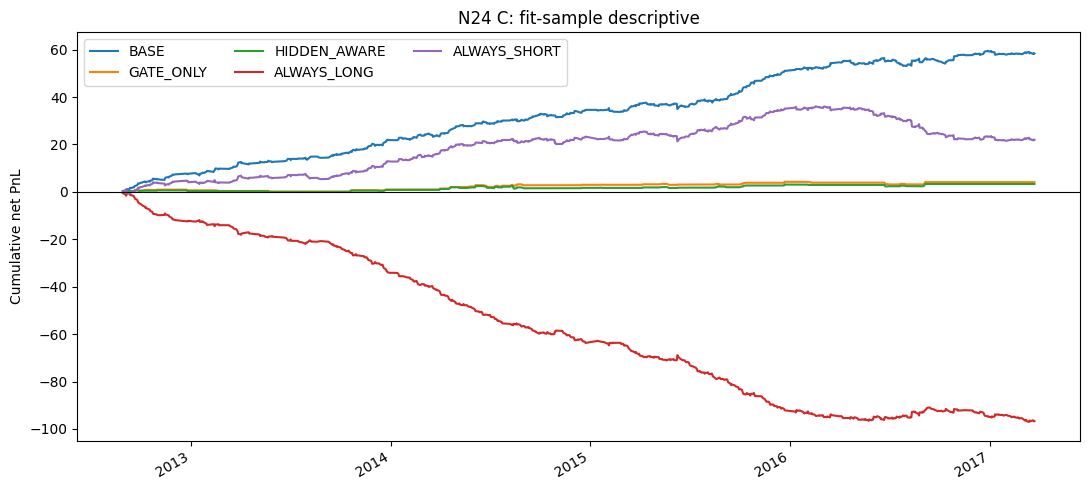

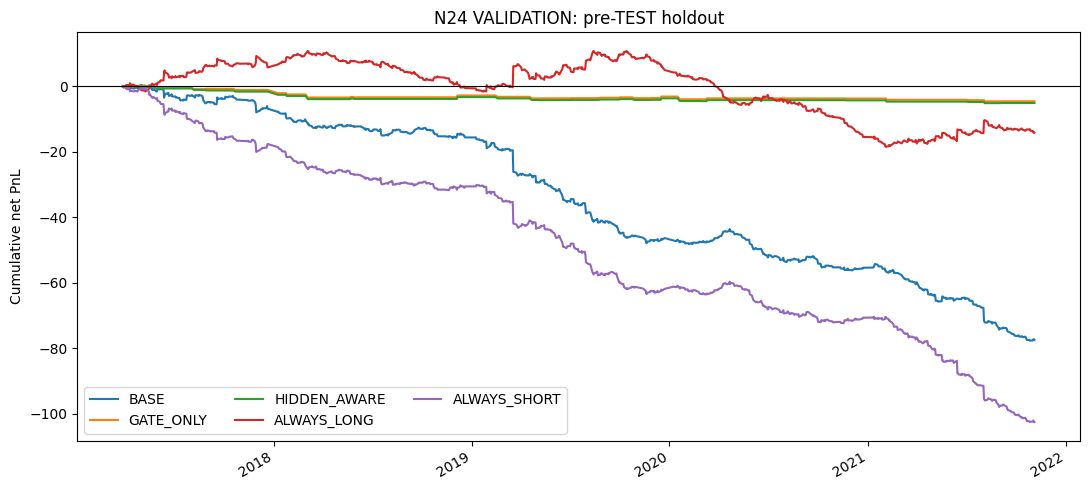

In [5]:
pre=pd.concat([c,v],ignore_index=True).sort_values(['stage','decision_model_day']).reset_index(drop=True)
pre['G_t']=pre.episode_entry.astype(int)
pre['z_BASE']=action(pre.Yhat_BASE,pre.c_entry_L,pre.c_entry_S)
pre['z_GATE_ONLY']=pre.z_BASE*pre.G_t
pre['z_HIDDEN_RAW']=action(pre.Yhat_HIDDEN_AWARE,pre.c_entry_L,pre.c_entry_S)
pre['z_HIDDEN_AWARE']=pre.z_HIDDEN_RAW*pre.G_t
assert (pre.z_GATE_ONLY==pre.z_BASE*pre.G_t).all()
policy={'FLAT':np.zeros(len(pre),int),'ALWAYS_LONG':np.ones(len(pre),int),'ALWAYS_SHORT':-np.ones(len(pre),int),
 'BASE':pre.z_BASE.to_numpy(),'GATE_ONLY':pre.z_GATE_ONLY.to_numpy(),'HIDDEN_AWARE':pre.z_HIDDEN_AWARE.to_numpy(),
 'GATED_ALWAYS_LONG':pre.G_t.to_numpy(),'GATED_ALWAYS_SHORT':-pre.G_t.to_numpy()}
for name,z in policy.items(): pre['z_'+name]=z

raw=[]; ac=[]; ec=[]
for stage,g in pre.groupby('stage',sort=False):
    for label,q in [('GATED',g[g.G_t.eq(1)]),('NON_GATED',g[g.G_t.eq(0)])]:
        raw.append({'stage':stage,'group':label,'n':len(q),'mean_Y_gross':q.Y_gross.mean(),'median_Y_gross':q.Y_gross.median(),
                    'std_Y_gross':q.Y_gross.std(ddof=1),'q10':q.Y_gross.quantile(.1),'q25':q.Y_gross.quantile(.25),
                    'q75':q.Y_gross.quantile(.75),'q90':q.Y_gross.quantile(.9)})
    for name,z in policy.items():
        zz=z[g.index]; ac.append({'stage':stage,'policy':name,**counts(zz)})
        ec.append({'stage':stage,'policy':name,**econ(zz,g.Y_net_L.to_numpy(),g.Y_net_S.to_numpy())})
raw_gate_target_diagnostic=pd.DataFrame(raw)
for stage in ['C','VALIDATION']:
    a=raw_gate_target_diagnostic[raw_gate_target_diagnostic.stage.eq(stage)].set_index('group')
    raw_gate_target_diagnostic.loc[raw_gate_target_diagnostic.stage.eq(stage),'mean_difference_gated_minus_nongated']=a.loc['GATED','mean_Y_gross']-a.loc['NON_GATED','mean_Y_gross']
    raw_gate_target_diagnostic.loc[raw_gate_target_diagnostic.stage.eq(stage),'median_difference_gated_minus_nongated']=a.loc['GATED','median_Y_gross']-a.loc['NON_GATED','median_Y_gross']
action_counts_pretest=pd.DataFrame(ac); economic_diagnostics_pretest=pd.DataFrame(ec)
policy_actions_pretest=pre[['decision_model_day','stage','G_t','c_entry_L','c_entry_S']+[f'z_{x}' for x in policy]].copy()
display(raw_gate_target_diagnostic); display(action_counts_pretest.query("policy in ['BASE','GATE_ONLY','HIDDEN_AWARE']")); display(economic_diagnostics_pretest)

for stage,g in pre.groupby('stage',sort=False):
    fig,ax=plt.subplots(figsize=(11,5))
    for name in ['BASE','GATE_ONLY','HIDDEN_AWARE','ALWAYS_LONG','ALWAYS_SHORT']:
        ax.plot(g.decision_model_day,np.cumsum(net(g['z_'+name],g.Y_net_L,g.Y_net_S)),label=name)
    ax.legend(ncol=3); ax.axhline(0,color='black',lw=.8); ax.set_ylabel('Cumulative net PnL')
    ax.set_title(f'N24 {stage}: '+('fit-sample descriptive' if stage=='C' else 'pre-TEST holdout'))
    fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(FIGURES/f'24_cumulative_net_pnl_{stage.lower()}.png',dpi=150); plt.show()

## 24.10 Predictive null benchmarks, scale audit, and frozen specification disk barrier

The zero and C-mean predictors are predictive benchmarks only; they do not enter GB selection. C is the fitting block. VALIDATION is the pre-TEST model-selection and diagnostic block; TEST/N25 is the first evaluation after the complete application specification is frozen.

The ZERO_FORECAST predictive benchmark and the FLAT economic benchmark are closely aligned in this application. A zero expected-gross-edge forecast lies inside the frozen positive entry-cost hurdle and therefore implies no trade. The predictive and economic metrics remain distinct.

In [6]:
# Predictive null benchmarks; neither is a GB candidate or an input to selection.
C_MEAN=float(c.Y_gross.mean())
benchmark_rows=[]
for stage,x in [('C',c),('VALIDATION',v)]:
    forecasts={'ZERO_FORECAST':np.zeros(len(x)),'C_MEAN_FORECAST':np.full(len(x),C_MEAN),
               'BASE':x.Yhat_BASE.to_numpy(),'HIDDEN_AWARE':x.Yhat_HIDDEN_AWARE.to_numpy(),
               **{f'BASE_NOISE_{seed}':x[f'Yhat_NOISE_{seed}'].to_numpy() for seed in NOISE_SEEDS}}
    for model,yhat in forecasts.items():
        q=metrics(x.Y_gross,yhat)
        benchmark_rows.append({'stage':stage,'model':model,**q})
predictive_benchmark_pretest=pd.DataFrame(benchmark_rows)
for stage in ['C','VALIDATION']:
    idx=predictive_benchmark_pretest.stage.eq(stage)
    z=float(predictive_benchmark_pretest.loc[idx & predictive_benchmark_pretest.model.eq('ZERO_FORECAST'),'MSE'].iloc[0])
    b=float(predictive_benchmark_pretest.loc[idx & predictive_benchmark_pretest.model.eq('BASE'),'MSE'].iloc[0])
    predictive_benchmark_pretest.loc[idx,'delta_MSE_vs_ZERO']=predictive_benchmark_pretest.loc[idx,'MSE']-z
    predictive_benchmark_pretest.loc[idx,'delta_MSE_vs_BASE']=predictive_benchmark_pretest.loc[idx,'MSE']-b
assert float(predictive_benchmark_pretest.query("stage=='VALIDATION' and model=='ZERO_FORECAST'").MSE.iloc[0]) == float(np.mean(v.Y_gross.to_numpy()**2))

# Candidate-grid scale audit is derived from the frozen 16-row table, not hard-coded.
base_candidate_mse=candidate_selection.VALIDATION_MSE
hidden_val=float(predictive_metrics_pretest.query("stage=='VALIDATION' and model=='HIDDEN_AWARE'").MSE.iloc[0])
base_val=float(predictive_metrics_pretest.query("stage=='VALIDATION' and model=='BASE'").MSE.iloc[0])
candidate_scale_audit=pd.DataFrame([{'candidate_MSE_minimum':base_candidate_mse.min(),'candidate_MSE_maximum':base_candidate_mse.max(),
 'candidate_MSE_absolute_range':base_candidate_mse.max()-base_candidate_mse.min(),
 'candidate_MSE_percentage_range_relative_to_winner':(base_candidate_mse.max()-base_candidate_mse.min())/base_candidate_mse.min()*100,
 'HIDDEN_AWARE_minus_BASE_winner_MSE':hidden_val-base_val,
 'HIDDEN_AWARE_percentage_change_vs_BASE':(hidden_val-base_val)/base_val*100,
 'n_BASE_candidates_worse_than_HIDDEN_AWARE':int((base_candidate_mse>hidden_val).sum()),
 'n_BASE_candidates_better_than_HIDDEN_AWARE':int((base_candidate_mse<hidden_val).sum())}])
assert len(candidate_selection)==16

# Snapshot pre-freeze scientific outputs for exact post-barrier invariance checks.
def digest(frame):
    return hashlib.sha256(pd.util.hash_pandas_object(frame.sort_index(axis=1),index=True).values.tobytes()).hexdigest()
candidate_before=candidate_selection.copy(); actions_before=policy_actions_pretest.copy(); economics_before=economic_diagnostics_pretest.copy(); noise_before=noise_capacity_control.copy()
flat_validation=float(economic_diagnostics_pretest.query("stage=='VALIDATION' and policy=='FLAT'").cumulative_net_pnl.iloc[0])
validation_econ=economic_diagnostics_pretest.query("stage=='VALIDATION'").set_index('policy')
flat_beats={name:bool(flat_validation>float(validation_econ.loc[name,'cumulative_net_pnl'])) for name in ['BASE','GATE_ONLY','HIDDEN_AWARE']}
zero_val=float(predictive_benchmark_pretest.query("stage=='VALIDATION' and model=='ZERO_FORECAST'").MSE.iloc[0])
cmean_val=float(predictive_benchmark_pretest.query("stage=='VALIDATION' and model=='C_MEAN_FORECAST'").MSE.iloc[0])
base_beats_cmean=bool(base_val<cmean_val); zero_beats_base=bool(zero_val<base_val)

display(predictive_benchmark_pretest)
display(candidate_scale_audit)
print('The incremental predictive effect of the hidden-response features is smaller than the variation in VALIDATION MSE across the predeclared BASE hyperparameter grid.')
print('VALIDATION ZERO MSE:',zero_val,'FLAT cumulative net PnL:',flat_validation,'ZERO beats BASE:',zero_beats_base,'FLAT beats BASE/GATE_ONLY/HIDDEN_AWARE:',flat_beats)

# Freeze specification and stop this cell at the disk barrier.
frozen_application_specification=pd.DataFrame([{'target':'Y_gross','BASE_features':' | '.join(BASE_FEATURES),
 'HIDDEN_AWARE_additions':' | '.join(HIDDEN_FEATURES),'support_rule':'R and I support >=3 of RF|GB|MLP|TRANSFORMER',
 'common_rule':'finite target, all BASE, support floor, all hidden coordinates','GB_parameters':str(frozen_params),
 'noise_seeds':'19 | 119 | 219','s_sigma_vol_points':.20,'gate':'frozen N22/N23 episode_entry','gate_only':'z_BASE * G_t',
 'hidden_aware':'z_HIDDEN_RAW * G_t','benchmarks':'ZERO_FORECAST | C_MEAN_FORECAST | FLAT | ALWAYS_LONG | ALWAYS_SHORT | GATED_ALWAYS_LONG | GATED_ALWAYS_SHORT',
 'reporting':'C fitting; VALIDATION pre-TEST model-selection/diagnostic; TEST/N25 first post-freeze evaluation'}])
frozen_application_specification.to_csv(PROCESSED/'24_frozen_application_specification.csv',index=False)
print('Frozen application specification written to disk; authoritative final refit occurs only in the next cell.')

,stage,model,MSE,RMSE,MAE,correlation,delta_MSE_vs_ZERO,delta_MSE_vs_BASE
0,C,ZERO_FORECAST,0.123682,0.351684,0.256813,NaN,0.000000,0.018380
1,C,C_MEAN_FORECAST,0.118250,0.343875,0.243920,NaN,-0.005432,0.012948
2,C,BASE,0.105302,0.324503,0.231979,0.399130,-0.018380,0.000000
3,C,HIDDEN_AWARE,0.100247,0.316618,0.226363,0.477920,-0.023435,-0.005055
4,C,BASE_NOISE_19,0.100907,0.317658,0.227250,0.471136,-0.022775,-0.004395
5,C,BASE_NOISE_119,0.101477,0.318554,0.229582,0.477036,-0.022205,-0.003825
6,C,BASE_NOISE_219,0.102364,0.319944,0.227993,0.474894,-0.021318,-0.002938
7,VALIDATION,ZERO_FORECAST,0.227221,0.476677,0.265084,NaN,0.000000,-0.006645
8,VALIDATION,C_MEAN_FORECAST,0.239878,0.489774,0.271326,NaN,0.012657,0.006012
9,VALIDATION,BASE,0.233866,0.483597,0.268410,0.033559,0.006645,0.000000


,candidate_MSE_minimum,candidate_MSE_maximum,candidate_MSE_absolute_range,candidate_MSE_percentage_range_relative_to_winner,HIDDEN_AWARE_minus_BASE_winner_MSE,HIDDEN_AWARE_percentage_change_vs_BASE,n_BASE_candidates_worse_than_HIDDEN_AWARE,n_BASE_candidates_better_than_HIDDEN_AWARE
0,0.233866,0.240547,0.006681,2.856788,0.002087,0.89245,12,4


The incremental predictive effect of the hidden-response features is smaller than the variation in VALIDATION MSE across the predeclared BASE hyperparameter grid.
VALIDATION ZERO MSE: 0.22722094663781317 FLAT cumulative net PnL: 0.0 ZERO beats BASE: True FLAT beats BASE/GATE_ONLY/HIDDEN_AWARE: {'BASE': True, 'GATE_ONLY': True, 'HIDDEN_AWARE': True}
Frozen application specification written to disk; authoritative final refit occurs only in the next cell.


## 24.11 Authoritative disk-reload final refit, TEST handoff, and invariance closure

This is the only authoritative final refit/TEST-handoff path: reload the frozen specification, refit on the 1,707 pre-TEST COMMON rows, construct outcome-free TEST features and actions, then verify the pre-reorder handoff is unchanged.

This export exposes the exact row-level VALIDATION predictions already computed by the frozen N24 application experiment. It introduces no new fit, model selection, feature construction, policy rule or economic result. Its sole purpose is to support post-hoc descriptive regime diagnostics.

In [7]:
# Reload and assert the frozen specification before the sole authoritative final refit.
reloaded_spec=read('24_frozen_application_specification.csv')
assert len(reloaded_spec)==1 and reloaded_spec.loc[0,'target']=='Y_gross'
assert reloaded_spec.loc[0,'BASE_features']==' | '.join(BASE_FEATURES)
assert reloaded_spec.loc[0,'HIDDEN_AWARE_additions']==' | '.join(HIDDEN_FEATURES)
assert reloaded_spec.loc[0,'GB_parameters']==str(frozen_params)
assert len(pre)==1707

# Authoritative C+VALIDATION refit: no re-selection and identical frozen hyperparameters.
final_base=GradientBoostingRegressor(**frozen_params).fit(pre[BASE_FEATURES],pre.Y_gross)
final_hidden=GradientBoostingRegressor(**frozen_params).fit(pre[ALL_FEATURES],pre.Y_gross)
final_noise={}
for seed in NOISE_SEEDS:
    q,cols=noisy(pre,seed)
    final_noise[seed]=GradientBoostingRegressor(**frozen_params).fit(q[BASE_FEATURES+cols],q.Y_gross)
fitted_model_registry={'BASE':final_base,'HIDDEN_AWARE':final_hidden,**{f'BASE_NOISE_{seed}':model for seed,model in final_noise.items()}}
gate_only_no_estimator='GATE_ONLY' not in fitted_model_registry
assert gate_only_no_estimator

# Strict TEST firewall: read only mechanics, features, gate and entry-known hurdles; never outcomes.
forbidden_test_outcomes={'Y_gross','Pi_gross','Y_net_L','Y_net_S','payoff_T','hedge_pnl_mid','V0_mid','c_spot_total_L','c_spot_total_S'}
test_contract=read('23_contract_admissibility_panel.csv',parse_dates=['model_day'],usecols=['model_day','stage','contract_admissible','episode_entry','Delta_L','common_log_response','P_R','P_I_prev'])
test_contract=test_contract[test_contract.stage.eq('TEST') & test_contract.contract_admissible.fillna(False)].copy()
test_cost=read('23_cost_grid_panel.csv',parse_dates=['model_day'],usecols=['model_day','stage','s_sigma_label','c_entry_L','c_entry_S'])
test_cost=test_cost[test_cost.stage.eq('TEST') & test_cost.s_sigma_label.eq('BASE')].drop(columns='s_sigma_label')
test_contract=test_contract.merge(test_cost,on=['model_day','stage'],how='left',validate='one_to_one')
test_panel=features(test_contract,False).sort_values('decision_model_day').reset_index(drop=True)
test=test_panel[test_panel.COMMON_complete].copy()
test['G_t']=test.episode_entry.astype(int)
forbidden_present=sorted(forbidden_test_outcomes.intersection(set(test_contract.columns)|set(test_panel.columns)|set(test.columns)))
test_firewall_audit=pd.DataFrame([{'object':'test_contract','forbidden_outcome_columns_present':' | '.join(sorted(forbidden_test_outcomes.intersection(test_contract.columns))) or 'EMPTY'},
 {'object':'test_feature_panel','forbidden_outcome_columns_present':' | '.join(sorted(forbidden_test_outcomes.intersection(test_panel.columns))) or 'EMPTY'},
 {'object':'test_common_handoff_input','forbidden_outcome_columns_present':' | '.join(sorted(forbidden_test_outcomes.intersection(test.columns))) or 'EMPTY'}])
assert forbidden_present==[]

# Generate outcome-free predictions and policy actions.
test['Yhat_BASE']=final_base.predict(test[BASE_FEATURES]); test['Yhat_HIDDEN_AWARE']=final_hidden.predict(test[ALL_FEATURES])
for seed,model in final_noise.items():
    q,cols=noisy(test,seed); test[f'Yhat_NOISE_{seed}']=model.predict(q[BASE_FEATURES+cols])
test['z_BASE']=action(test.Yhat_BASE,test.c_entry_L,test.c_entry_S)
test['z_GATE_ONLY']=test.z_BASE*test.G_t
test['z_HIDDEN_RAW']=action(test.Yhat_HIDDEN_AWARE,test.c_entry_L,test.c_entry_S)
test['z_HIDDEN_AWARE']=test.z_HIDDEN_RAW*test.G_t
assert (test.z_GATE_ONLY==test.z_BASE*test.G_t).all()
assert (test.z_HIDDEN_AWARE==test.z_HIDDEN_RAW*test.G_t).all()
PRED=['Yhat_BASE','Yhat_HIDDEN_AWARE','Yhat_NOISE_19','Yhat_NOISE_119','Yhat_NOISE_219']; ACT=['z_BASE','z_GATE_ONLY','z_HIDDEN_RAW','z_HIDDEN_AWARE']; KEY='decision_model_day'
test_prediction_policy_handoff=test[['decision_model_day','forecast_target_model_day','stage','G_t','c_entry_L','c_entry_S','R_model_support','I_model_support',*PRED,*ACT]].copy()
test_feature_availability_audit=pd.DataFrame([{'stage':'TEST','N23_admissible':len(test_panel),'BASE_complete':int(test_panel.BASE_complete.sum()),
 'hidden_coordinate_complete':int(test_panel.hidden_coordinates_complete.sum()),'COMMON_complete':int(test_panel.COMMON_complete.sum()),
 'gate_entries_surviving_COMMON':int(test.G_t.sum()),'R_support_ge_3':int((test_panel.R_model_support>=3).sum()),'I_support_ge_3':int((test_panel.I_model_support>=3).sum()),
 'forbidden_TEST_outcomes_present':' | '.join(forbidden_present) if forbidden_present else 'EMPTY','TEST_outcomes_loaded':'YES' if forbidden_present else 'NO','TEST_economics_inspected':'YES' if forbidden_present else 'NO'}])

# Existing pre-reorder snapshot and keyed invariance audit; it remains an order/provenance test only.
reference=read('24_pre_reorder_test_handoff_snapshot.csv',parse_dates=[KEY],usecols=[KEY]+PRED+ACT).sort_values(KEY).reset_index(drop=True)
new=test_prediction_policy_handoff[[KEY]+PRED+ACT].sort_values(KEY).reset_index(drop=True)
comp=reference.merge(new,on=KEY,how='outer',suffixes=('_old','_new'),indicator=True,validate='one_to_one')
assert comp._merge.eq('both').all()
audit=[]; diffs=[]
for col in PRED:
    old,newv=comp[f'{col}_old'].to_numpy(float),comp[f'{col}_new'].to_numpy(float); ok=np.isclose(old,newv,rtol=0,atol=1e-12,equal_nan=True)
    audit.append({'model':col,'kind':'prediction','n_rows':len(ok),'n_different':int((~ok).sum()),'max_absolute_difference':float(np.nanmax(abs(old-newv))),'pass_rtol_0_atol_1e_12':bool(ok.all())})
    for day,o,nv in zip(comp.loc[~ok,KEY],old[~ok],newv[~ok]): diffs.append({'model':col,'model_day':day,'old_prediction':o,'new_prediction':nv,'absolute_difference':abs(o-nv),'kind':'prediction'})
for col in ACT:
    ok=comp[f'{col}_old'].eq(comp[f'{col}_new'])
    audit.append({'model':col,'kind':'action','n_rows':len(ok),'n_different':int((~ok).sum()),'max_absolute_difference':float((comp.loc[~ok,f'{col}_old']-comp.loc[~ok,f'{col}_new']).abs().max()) if (~ok).any() else 0.,'pass_rtol_0_atol_1e_12':bool(ok.all())})
    for _,r in comp.loc[~ok,[KEY,f'{col}_old',f'{col}_new']].iterrows(): diffs.append({'model':col,'model_day':r[KEY],'old_prediction':r[f'{col}_old'],'new_prediction':r[f'{col}_new'],'absolute_difference':abs(r[f'{col}_old']-r[f'{col}_new']),'kind':'action'})
final_refit_reorder_invariance=pd.DataFrame(audit); final_refit_reorder_differences=pd.DataFrame(diffs,columns=['model','model_day','old_prediction','new_prediction','absolute_difference','kind'])
pred_diff=set(final_refit_reorder_differences.loc[final_refit_reorder_differences.kind.eq('prediction'),'model'])
movement_scope='NO_MOVEMENT' if not pred_diff else ('NOISE_CONTROL_ONLY' if pred_diff.issubset(set(PRED[2:])) else 'BASE_OR_HIDDEN_AWARE_MOVEMENT')
assert final_refit_reorder_invariance.pass_rtol_0_atol_1e_12.all()

# Pre/post final-refit MSE: before values are deterministically recoverable from the frozen recipe.
def final_mse(name,model):
    if name=='BASE': x=pre[BASE_FEATURES]
    elif name=='HIDDEN_AWARE': x=pre[ALL_FEATURES]
    else:
        seed=int(name.rsplit('_',1)[1]); q,cols=noisy(pre,seed); x=q[BASE_FEATURES+cols]
    return mean_squared_error(pre.Y_gross,model.predict(x))
post_models={'BASE':final_base,'HIDDEN_AWARE':final_hidden,**{f'BASE_NOISE_{s}':m for s,m in final_noise.items()}}
# The pre-edit models use the same deterministic frozen recipe; recompute solely to record their recoverable in-sample MSE.
pre_models={'BASE':GradientBoostingRegressor(**frozen_params).fit(pre[BASE_FEATURES],pre.Y_gross),
 'HIDDEN_AWARE':GradientBoostingRegressor(**frozen_params).fit(pre[ALL_FEATURES],pre.Y_gross)}
for seed in NOISE_SEEDS:
    q,cols=noisy(pre,seed); pre_models[f'BASE_NOISE_{seed}']=GradientBoostingRegressor(**frozen_params).fit(q[BASE_FEATURES+cols],q.Y_gross)
final_refit_mse_reorder_invariance=pd.DataFrame([{'model':name,'pre_reorder_MSE':final_mse(name,pre_models[name]),'pre_edit_value_recoverable':True,'post_reorder_MSE':final_mse(name,model)} for name,model in post_models.items()])
final_refit_mse_reorder_invariance['absolute_difference']=abs(final_refit_mse_reorder_invariance.post_reorder_MSE-final_refit_mse_reorder_invariance.pre_reorder_MSE)
final_refit_mse_reorder_invariance['unchanged_rtol_0_atol_1e_12']=final_refit_mse_reorder_invariance.absolute_difference.le(1e-12)
assert final_refit_mse_reorder_invariance.unchanged_rtol_0_atol_1e_12.all()

# Provenance and scientific invariance derived from actual objects, not literals.
upstream_hash_after={path.name:file_hash(path) for path in UPSTREAM_NOTEBOOKS}
upstream_unchanged=UPSTREAM_HASH_BEFORE==upstream_hash_after
assert upstream_unchanged
pretest_scientific_unchanged=(digest(candidate_before)==digest(candidate_selection) and digest(actions_before)==digest(policy_actions_pretest) and digest(economics_before)==digest(economic_diagnostics_pretest) and digest(noise_before)==digest(noise_capacity_control))
assert pretest_scientific_unchanged

# Export-only provenance amendment: direct view of the already computed frozen validation dataframe v.
PRED_EXPORT=['Yhat_BASE','Yhat_HIDDEN_AWARE','Yhat_NOISE_19','Yhat_NOISE_119','Yhat_NOISE_219']
VALIDATION_EXPORT_COLS=['decision_model_day','forecast_target_model_day','stage',*PRED_EXPORT]
validation_prediction_handoff=v[VALIDATION_EXPORT_COLS].copy().sort_values('decision_model_day').reset_index(drop=True)
validation_common_days=set(pre.loc[pre.stage.eq('VALIDATION'),'decision_model_day'])
assert len(validation_prediction_handoff)==902 and validation_prediction_handoff.decision_model_day.is_unique
assert validation_prediction_handoff.forecast_target_model_day.notna().all() and validation_prediction_handoff.stage.eq('VALIDATION').all()
assert validation_prediction_handoff[PRED_EXPORT].apply(lambda x:np.isfinite(x)).all().all()
assert set(validation_prediction_handoff.decision_model_day)==validation_common_days
# Keyed direct in-memory source equality before serialization: no reconstruction and no separate fit.
source_check=v[VALIDATION_EXPORT_COLS].copy().sort_values('decision_model_day').reset_index(drop=True)
source_residuals={col:float(np.max(np.abs(validation_prediction_handoff[col].to_numpy()-source_check[col].to_numpy()))) for col in PRED_EXPORT}
assert all(value==0.0 for value in source_residuals.values())
validation_prediction_handoff.to_csv(PROCESSED/'24_validation_prediction_handoff.csv',index=False)
validation_prediction_roundtrip=read('24_validation_prediction_handoff.csv',parse_dates=['decision_model_day','forecast_target_model_day']).sort_values('decision_model_day').reset_index(drop=True)
roundtrip_residuals={col:float(np.max(np.abs(validation_prediction_handoff[col].to_numpy()-validation_prediction_roundtrip[col].to_numpy()))) for col in PRED_EXPORT}
assert all(np.isclose(value,0.0,rtol=0,atol=1e-12) for value in roundtrip_residuals.values())
validation_prediction_export_audit=pd.DataFrame([{'exported_rows':len(validation_prediction_handoff),'unique_decision_model_days':int(validation_prediction_handoff.decision_model_day.nunique()),'stage_values':' | '.join(sorted(validation_prediction_handoff.stage.unique())),'source_object':'frozen VALIDATION COMMON dataframe v','new_model_fit_created_for_export':False,'reconstruction_or_inversion_used':False,'in_memory_source_equality_pass':all(value==0.0 for value in source_residuals.values()),**{f'source_max_abs_residual_{col}':source_residuals[col] for col in PRED_EXPORT},**{f'roundtrip_max_abs_residual_{col}':roundtrip_residuals[col] for col in PRED_EXPORT}}])
# Capture currently frozen outputs before the regular N24 export writes below.
candidate_disk_before=read('24_gb_candidate_selection.csv'); predictive_disk_before=read('24_predictive_metrics_pretest.csv'); benchmark_disk_before=read('24_predictive_benchmark_pretest.csv'); noise_disk_before=read('24_noise_capacity_control.csv'); actions_disk_before=read('24_policy_actions_pretest.csv',parse_dates=['decision_model_day']); economics_disk_before=read('24_economic_diagnostics_pretest.csv'); test_disk_before=read('24_test_prediction_policy_handoff.csv',parse_dates=['decision_model_day'])
def numeric_same(left,right,cols): return np.allclose(left[cols].to_numpy(float),right[cols].to_numpy(float),rtol=0,atol=1e-12,equal_nan=True)
candidate_mse_unchanged=numeric_same(candidate_selection.sort_values('candidate_id'),candidate_disk_before.sort_values('candidate_id'),['VALIDATION_MSE'])
predictive_results_unchanged=numeric_same(predictive_metrics_pretest.sort_values(['stage','model']),predictive_disk_before.sort_values(['stage','model']),['MSE','RMSE','MAE','correlation'])
zero_benchmark_unchanged=numeric_same(predictive_benchmark_pretest.sort_values(['stage','model']),benchmark_disk_before.sort_values(['stage','model']),['MSE'])
noise_mse_unchanged=numeric_same(noise_capacity_control.sort_values('seed'),noise_disk_before.sort_values('seed'),['MSE','RMSE','MAE','correlation'])
actions_unchanged=policy_actions_pretest.sort_values(['stage','decision_model_day']).reset_index(drop=True).equals(actions_disk_before.sort_values(['stage','decision_model_day']).reset_index(drop=True))
economics_unchanged=numeric_same(economic_diagnostics_pretest.sort_values(['stage','policy']),economics_disk_before.sort_values(['stage','policy']),[c for c in economic_diagnostics_pretest.columns if c not in ['stage','policy']])
test_prediction_unchanged=numeric_same(test_prediction_policy_handoff.sort_values('decision_model_day'),test_disk_before.sort_values('decision_model_day'),PRED)
test_actions_unchanged=test_prediction_policy_handoff.sort_values('decision_model_day')[ACT].reset_index(drop=True).equals(test_disk_before.sort_values('decision_model_day')[ACT].reset_index(drop=True))
common_export=pre[['decision_model_day','forecast_target_model_day','stage','Y_gross','episode_entry','G_t','R_model_support','I_model_support','BASE_feature_finite','hidden_coordinates_complete','BASE_complete','COMMON_complete',*BASE_FEATURES,*HIDDEN_FEATURES]].copy()
final_refit_manifest=pd.DataFrame([{'model':'BASE','rows':1707,'features':' | '.join(BASE_FEATURES),'parameters':str(frozen_params)},
 {'model':'HIDDEN_AWARE','rows':1707,'features':' | '.join(ALL_FEATURES),'parameters':str(frozen_params)},
 *[{'model':f'BASE+NOISE_{s}','rows':1707,'features':'BASE + four noise features','parameters':str(frozen_params)} for s in NOISE_SEEDS]])
exports={'24_application_common_feature_panel_pretest.csv':common_export,'24_application_feature_definition.csv':feature_definition,'24_gb_candidate_selection.csv':candidate_selection,'24_gb_depth_comparison.csv':depth_comparison,'24_noise_capacity_control.csv':noise_capacity_control,'24_predictive_metrics_pretest.csv':predictive_metrics_pretest,'24_predictive_benchmark_pretest.csv':predictive_benchmark_pretest,'24_candidate_scale_audit.csv':candidate_scale_audit,'24_feature_importance.csv':feature_importance,'24_policy_actions_pretest.csv':policy_actions_pretest,'24_action_counts_pretest.csv':action_counts_pretest,'24_raw_gate_target_diagnostic.csv':raw_gate_target_diagnostic,'24_economic_diagnostics_pretest.csv':economic_diagnostics_pretest,'24_frozen_application_specification.csv':frozen_application_specification,'24_final_refit_manifest.csv':final_refit_manifest,'24_test_feature_availability_audit.csv':test_feature_availability_audit,'24_test_firewall_audit.csv':test_firewall_audit,'24_test_prediction_policy_handoff.csv':test_prediction_policy_handoff,'24_final_refit_reorder_invariance.csv':final_refit_reorder_invariance,'24_final_refit_reorder_differences.csv':final_refit_reorder_differences,'24_final_refit_mse_reorder_invariance.csv':final_refit_mse_reorder_invariance,'24_pre_reorder_test_handoff_snapshot.csv':reference,'24_validation_prediction_handoff.csv':validation_prediction_handoff,'24_validation_prediction_export_audit.csv':validation_prediction_export_audit}
for name,x in exports.items(): x.to_csv(PROCESSED/name,index=False)
checks={'C_COMMON_805':len(c)==805,'VALIDATION_COMMON_902':len(v)==902,'preTEST_COMMON_1707':len(pre)==1707,'C_gate_68':int(c.episode_entry.sum())==68,'VALIDATION_gate_34':int(v.episode_entry.sum())==34,'combined_gate_102':int(pre.G_t.sum())==102,'all_16_candidates':len(candidate_selection)==16,'winner_validation_MSE_only':winner.VALIDATION_MSE==candidate_selection.VALIDATION_MSE.min(),'specification_written_before_final_refit':(PROCESSED/'24_frozen_application_specification.csv').exists(),'specification_reloaded':len(reloaded_spec)==1,'explicit_upstream_N14_N23_only':all(not path.name.startswith('24_') for path in UPSTREAM_NOTEBOOKS),'upstream_notebooks_unchanged':upstream_unchanged,'forbidden_TEST_outcomes_EMPTY':forbidden_present==[],'TEST_economics_inspected_NO':not forbidden_present,'GATE_ONLY_no_estimator':gate_only_no_estimator,'GATE_ONLY_mask_exact':(test.z_GATE_ONLY==test.z_BASE*test.G_t).all(),'candidate_noise_actions_economics_unchanged':pretest_scientific_unchanged,'reorder_invariance_NO_MOVEMENT':movement_scope=='NO_MOVEMENT','final_refit_mse_unchanged':final_refit_mse_reorder_invariance.unchanged_rtol_0_atol_1e_12.all(),'TEST_handoff_901':len(test_prediction_policy_handoff)==901,'TEST_handoff_outcome_free':not forbidden_present,'validation_prediction_export_902':len(validation_prediction_handoff)==902,'validation_prediction_source_equality':all(value==0.0 for value in source_residuals.values()),'validation_prediction_roundtrip':all(np.isclose(value,0.0,rtol=0,atol=1e-12) for value in roundtrip_residuals.values()),'candidate_MSEs_unchanged':candidate_mse_unchanged,'zero_benchmark_unchanged':zero_benchmark_unchanged,'predictive_results_unchanged':predictive_results_unchanged,'noise_MSEs_unchanged':noise_mse_unchanged,'pretest_actions_unchanged':actions_unchanged,'pretest_economics_unchanged':economics_unchanged,'TEST_predictions_actions_unchanged':test_prediction_unchanged and test_actions_unchanged}
application_closure=pd.DataFrame({'check':checks.keys(),'pass':checks.values()}); assert application_closure['pass'].all()
application_closure.to_csv(PROCESSED/'24_application_closure.csv',index=False); exports['24_application_closure.csv']=application_closure
manifest=pd.DataFrame([{'file':name,'rows':len(x),'exists':(PROCESSED/name).exists()} for name,x in exports.items()]); manifest=pd.concat([manifest,pd.DataFrame([{'file':'24_export_manifest.csv','rows':len(manifest)+1,'exists':True}])],ignore_index=True); manifest.to_csv(PROCESSED/'24_export_manifest.csv',index=False)
display(test_firewall_audit); display(final_refit_reorder_invariance); display(final_refit_mse_reorder_invariance)
print('N24 FINAL FREEZE / NULL-BENCHMARK CLOSURE')
print('COMMON C/VALIDATION:',len(c),len(v),'winner unchanged:',dict(winner[['n_estimators','learning_rate','max_depth','min_samples_leaf']]))
print('BASE/HIDDEN VALIDATION MSE and hidden % change:',base_val,hidden_val,(hidden_val-base_val)/base_val*100)
print(candidate_scale_audit.to_dict('records')[0]); print('ZERO/C_MEAN VALIDATION MSE:',zero_val,cmean_val,'ZERO beats BASE:',zero_beats_base,'BASE beats C_MEAN:',base_beats_cmean)
print('Noise unchanged YES; actions/economics unchanged YES; FLAT VALIDATION cumulative PnL:',flat_validation,'FLAT beats:',flat_beats)
print('spec written/reloaded YES/YES; upstream explicit N14-N23 only YES; upstream modified NONE')
print('forbidden TEST outcomes NONE; TEST economics inspected NO; GATE_ONLY fitted estimator exists NO; mask PASS')
print('final refit rows 1707; reorder invariance',movement_scope,'; TEST handoff rows',len(test_prediction_policy_handoff),'outcome-free PASS; execution errors 0')
print('N24 VALIDATION PREDICTION EXPORT AMENDMENT')
print('amendment EXPORT ONLY; source frozen VALIDATION COMMON dataframe v; new model fit NO; reconstruction NO')
print('export 24_validation_prediction_handoff.csv rows',len(validation_prediction_handoff),'unique days',validation_prediction_handoff.decision_model_day.nunique(),'stage',validation_prediction_handoff.stage.unique())
print('source equality PASS; round-trip residuals',roundtrip_residuals)
print('scientific invariance candidate/zero/predictive/noise/actions/economics:',candidate_mse_unchanged,zero_benchmark_unchanged,predictive_results_unchanged,noise_mse_unchanged,actions_unchanged,economics_unchanged)
print('TEST predictions/actions unchanged',test_prediction_unchanged and test_actions_unchanged,'forbidden TEST outcomes NONE; upstream modified NONE; scientific specification changed NO')
print('N24 VALIDATION PREDICTION EXPORT SAFE: YES')
print('N24 FROZEN FOR N25: YES')

,object,forbidden_outcome_columns_present
0,test_contract,EMPTY
1,test_feature_panel,EMPTY
2,test_common_handoff_input,EMPTY


,model,kind,n_rows,n_different,max_absolute_difference,pass_rtol_0_atol_1e_12
0,Yhat_BASE,prediction,901,0,9.714451e-17,True
1,Yhat_HIDDEN_AWARE,prediction,901,0,9.887924e-17,True
2,Yhat_NOISE_19,prediction,901,0,9.952976e-17,True
3,Yhat_NOISE_119,prediction,901,0,9.974660e-17,True
4,Yhat_NOISE_219,prediction,901,0,9.801188e-17,True
5,z_BASE,action,901,0,0.000000e+00,True
6,z_GATE_ONLY,action,901,0,0.000000e+00,True
7,z_HIDDEN_RAW,action,901,0,0.000000e+00,True
8,z_HIDDEN_AWARE,action,901,0,0.000000e+00,True


,model,pre_reorder_MSE,pre_edit_value_recoverable,post_reorder_MSE,absolute_difference,unchanged_rtol_0_atol_1e_12
0,BASE,0.158638,True,0.158638,0.0,True
1,HIDDEN_AWARE,0.154100,True,0.154100,0.0,True
2,BASE_NOISE_19,0.156210,True,0.156210,0.0,True
3,BASE_NOISE_119,0.157233,True,0.157233,0.0,True
4,BASE_NOISE_219,0.156294,True,0.156294,0.0,True


N24 FINAL FREEZE / NULL-BENCHMARK CLOSURE
COMMON C/VALIDATION: 805 902 winner unchanged: {'n_estimators': np.float64(250.0), 'learning_rate': np.float64(0.03), 'max_depth': np.float64(2.0), 'min_samples_leaf': np.float64(40.0)}
BASE/HIDDEN VALIDATION MSE and hidden % change: 0.2338657069467221 0.23595284045105455 0.8924495735528827
{'candidate_MSE_minimum': 0.2338657069467221, 'candidate_MSE_maximum': 0.24054675384552268, 'candidate_MSE_absolute_range': 0.0066810468988005856, 'candidate_MSE_percentage_range_relative_to_winner': 2.8567877633819236, 'HIDDEN_AWARE_minus_BASE_winner_MSE': 0.0020871335043324557, 'HIDDEN_AWARE_percentage_change_vs_BASE': 0.8924495735528827, 'n_BASE_candidates_worse_than_HIDDEN_AWARE': 12, 'n_BASE_candidates_better_than_HIDDEN_AWARE': 4}
ZERO/C_MEAN VALIDATION MSE: 0.22722094663781317 0.23987817031713812 ZERO beats BASE: True BASE beats C_MEAN: True
Noise unchanged YES; actions/economics unchanged YES; FLAT VALIDATION cumulative PnL: 0.0 FLAT beats: {'BASE': 